#  MuJoCo Bootcamp : Projectile Launch

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---


### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/XStRXoEGE70

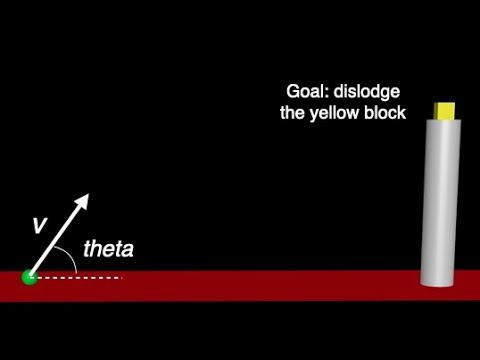

In [6]:
from IPython.display import YouTubeVideo

YouTubeVideo('XStRXoEGE70')

## Run python code

In [ ]:
!python hopper.py 

## Jupyter code

### Load XML file and build model and data

In [ ]:
import mujoco as mj
import numpy as np
import mediapy as media
from numpy.linalg import inv
from scipy.linalg import solve_continuous_are
import os

NLOPT_IMPORTED = True
#NOTE: If this gives numpy error try,  pip install numpy --upgrade
try:
    import nlopt
except ImportError:
    print("nlopt not imported, switching to pre-computed solution")
    NLOPT_IMPORTED = False

# Create an XML file string for a simple ball on a plane
xml_path = "./ball.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [ ]:
def controller(model, data):
    #put the controller here
    pass

def simulator(x):
    v, theta, time_of_flight = x[0], x[1], x[2]

    data.qvel[0] = v * np.cos(theta)
    data.qvel[2] = v * np.sin(theta)

    while data.time < time_of_flight:
        # Step simulation environment
        mj.mj_step(model, data)

    # Get position
    pos = np.array([data.qpos[0], data.qpos[2]])

    # Reset Data
    mj.mj_resetData(model, data)

    return pos

def init_controller(model,data):

    # Set initial guess
    v = 10.0
    theta = np.pi / 4
    time_of_flight = 2.0

    if NLOPT_IMPORTED:
        sol = optimize_ic(np.array([v, theta, time_of_flight]))
    else:
        sol = np.array([9.398687489285555, 1.2184054599970882, 1.5654456340479144])

    v_sol, theta_sol = sol[0], sol[1]
    simend = sol[2] + 2

    data.qvel[0] = v_sol * np.cos(theta_sol)
    data.qvel[2] = v_sol * np.sin(theta_sol)

def cost_func(x, grad):
    cost = 0.0
    return cost

def equality_constraints(result, x, grad):
    """
    For details of the API please refer to:
    https://nlopt.readthedocs.io/en/latest/NLopt_Python_Reference/#:~:text=remove_inequality_constraints()%0Aopt.remove_equality_constraints()-,Vector%2Dvalued%20constraints,-Just%20as%20for
    Note: Please open the link in Chrome
    """
    pos = simulator(x)
    result[0] = pos[0] - 5.0
    result[1] = pos[1] - 2.1

def optimize_ic(x):
    """
    Optimization problem is

         min_X      0
    subject to 0.1 ≤ v ≤ ∞
               0.1 ≤ θ ≤ π/2
               0.1 ≤ T ≤ ∞
               x(T) = x^*
               z(T) = z^*

    with X = [v, θ, T]
    """
    # Define optimization problem
    opt = nlopt.opt(nlopt.LN_COBYLA, 3)

    # Define lower and upper bounds
    opt.set_lower_bounds([0.1, 0.1, 0.1])
    opt.set_upper_bounds([10000.0, np.pi / 2 - 0.1, 10000.0])

    # Set objective funtion
    opt.set_min_objective(cost_func)

    # Define equality constraints
    tol = [1e-4, 1e-4]
    opt.add_equality_mconstraint(equality_constraints, tol)

    # Set relative tolerance on optimization parameters
    opt.set_xtol_rel(1e-4)

    # Solve problem
    sol = opt.optimize(x)

    return sol

### Setup the configuration of render

In [ ]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()                        # Abstract camera
opt = mj.MjvOption()                        # visualization options
mj.mjv_defaultCamera(cam)
mj.mjv_defaultOption(opt)
# Set camera configuration
cam.azimuth = 89.608063
cam.elevation = -11.588379
cam.distance = 5.0
cam.lookat = np.array([0.0, 0.0, 1.5])

### Initialization 

In [ ]:
#initialize the controller
init_controller(model,data)

#set the controller
mj.set_mjcb_control(controller)



### Simulation

In [ ]:
# Store frames for visualization
frames = []
framerate = 60
simend = 5
simstart = data.time
# mj.mj_resetData(model, data)
# init_controller(model,data)

while data.time < simend:
    simstart = data.time
    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    cam.lookat[0] = data.qpos[0] #camera moves with the ball
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)




This browser does not support the video tag.
